In [2]:
import zipfile
import pathlib
import os

In [3]:
import kagglehub

path = kagglehub.dataset_download("masoudnickparvar/white-blood-cells-dataset")

In [4]:
path = pathlib.Path(path)

In [5]:
train_dir = path / "Train"

test_a_dir = path / "Test-A"
test_b_dir = path / "Test-B"

In [6]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader

import torchvision
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder

In [7]:
cpu_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.uint8)
])

label_transform = v2.Compose([
    v2.ToDtype(torch.long)
])

gpu_train_transform = nn.Sequential(
    v2.Resize((512, 512), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(15),
    v2.RandomAdjustSharpness(sharpness_factor=2.0),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
)

gpu_test_transform = nn.Sequential(
    v2.Resize((512, 512), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
)


gpu_train_transform, gpu_test_transform = gpu_train_transform.to('cuda'), gpu_test_transform.to('cuda')

In [8]:
train_dataset = ImageFolder(root=train_dir, transform=cpu_transform, target_transform=label_transform)
test_dataset = ImageFolder(root=test_a_dir, transform=cpu_transform, target_transform=label_transform)

In [9]:
import numpy as np

In [23]:
from torch.utils.data import WeightedRandomSampler

targets = train_dataset.targets
class_counts = np.bincount(targets)
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)

sample_weights = [class_weights[label] for label in targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

BATCH_SIZE = 4

train_dataloader = DataLoader(train_dataset,
                              BATCH_SIZE,
                              sampler=sampler,
                              pin_memory=True,
                              num_workers=2,
                              prefetch_factor=2,
                              persistent_workers=True)

test_dataloader = DataLoader(test_dataset,
                             BATCH_SIZE,
                             shuffle=True,
                             pin_memory=True,
                             num_workers=2,
                             prefetch_factor=2,
                             persistent_workers=True)

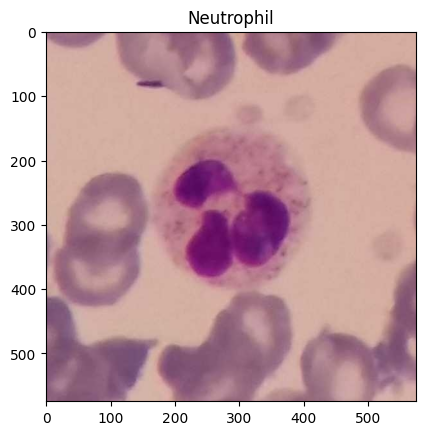

In [24]:
import matplotlib.pyplot as plt
import random

sample = random.choice(test_dataset)

plt.imshow(sample[0].permute(1, 2, 0))
plt.title(train_dataset.classes[sample[1]]);

In [25]:
import timm

model = timm.create_model('densenet121', pretrained=True, memory_efficient=True) # set memory_efficient to true if unfreezing backbone

In [26]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [27]:
in_features = model.classifier.in_features

model.classifier = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 5)
)

In [28]:
model.to(device)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNormAct2d(
      64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): DenseBlock(
      (denselayer1): DenseLayer(
        (norm1): BatchNormAct2d(
          64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNormAct2d(
          128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
  

In [29]:
import torchinfo

torchinfo.summary(model)

Layer (type:depth-idx)                        Param #
DenseNet                                      --
├─Sequential: 1-1                             --
│    └─Conv2d: 2-1                            9,408
│    └─BatchNormAct2d: 2-2                    128
│    │    └─Identity: 3-1                     --
│    │    └─ReLU: 3-2                         --
│    └─MaxPool2d: 2-3                         --
│    └─DenseBlock: 2-4                        --
│    │    └─DenseLayer: 3-3                   45,440
│    │    └─DenseLayer: 3-4                   49,600
│    │    └─DenseLayer: 3-5                   53,760
│    │    └─DenseLayer: 3-6                   57,920
│    │    └─DenseLayer: 3-7                   62,080
│    │    └─DenseLayer: 3-8                   66,240
│    └─DenseTransition: 2-5                   --
│    │    └─BatchNormAct2d: 3-9               512
│    │    └─Conv2d: 3-10                      32,768
│    │    └─AvgPool2d: 3-11                   --
│    └─DenseBlock: 2-6         

In [30]:
device

'cuda'

In [31]:
import torchmetrics
from torchmetrics.classification import MulticlassPrecision, MulticlassRecall, MulticlassF1Score, MulticlassConfusionMatrix
from torchmetrics.wrappers import ClasswiseWrapper

In [32]:
n_classes = 5
classes = train_dataset.classes

a_steps = 8

EPOCHS = 40
WARMUP_EPOCHS = 5

class_weights = torch.tensor([0.5, 3.5, 1.3, 3.0, 0.6]).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1, weight=class_weights)

optimizer = optim.AdamW([
    {'params': model.features.parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
])

warmup_scheduler = optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=WARMUP_EPOCHS
)

cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=(EPOCHS - WARMUP_EPOCHS),
    eta_min=1e-7
)

scheduler = optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS]
)

scaler = torch.amp.GradScaler(device)

precision = ClasswiseWrapper(MulticlassPrecision(num_classes=n_classes, average='none'), labels=classes).to(device)
recall = ClasswiseWrapper(MulticlassRecall(num_classes=n_classes, average='none'), labels=classes).to(device)
f1 = ClasswiseWrapper(MulticlassF1Score(num_classes=n_classes, average='none'), labels=classes).to(device)

In [33]:
torch.cuda.empty_cache()

In [34]:
best_f1 = 0

for epoch in range(EPOCHS):
    torch.cuda.empty_cache()

    model.train()

    train_loss = 0

    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)
        X = gpu_train_transform(X)

        with torch.amp.autocast(device_type=device):
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss /= a_steps

        scaler.scale(loss).backward()

        if (batch + 1) % a_steps == 0 or (batch + 1) == len(train_dataloader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        train_loss += loss.item() * a_steps

    train_loss /= len(train_dataloader)

    scheduler.step()

    model.eval()

    test_loss = 0

    precision.reset()
    recall.reset()
    f1.reset()

    with torch.inference_mode():
        for batch, (X, y) in enumerate(test_dataloader):
            X, y = X.to(device), y.to(device)

            X = gpu_test_transform(X)

            y_hat = model(X)

            loss = criterion(y_hat, y)

            preds = torch.argmax(y_hat, dim=1)

            precision.update(preds, y)
            recall.update(preds, y)
            f1.update(preds, y)

            test_loss += loss.item()

    test_loss /= len(test_dataloader)


    print(f"EPOCH: {epoch} | Train Loss: {train_loss:.2f} | Test Loss: {test_loss:.2f} | LR: {optimizer.param_groups[0]['lr']}\n")

    p_dict = precision.compute()
    r_dict = recall.compute()
    f1_dict = f1.compute()

    f1_mean = sum(f1_dict.values()) / len(f1_dict.values())

    if f1_mean > best_f1:
        torch.save(model.state_dict(), f='ckpt.pth')

    print(f"{'Class':<15} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
    print("-" * 55)

    for cls in train_dataset.classes:
        p = p_dict[f'multiclassprecision_{cls}'].item()
        r = r_dict[f'multiclassrecall_{cls}'].item()
        f1_val = f1_dict[f'multiclassf1score_{cls}'].item()

        print(f"{cls:<15} | {p:<10.4f} | {r:<10.4f} | {f1_val:<10.4f}")

    print("\n\n")



EPOCH: 0 | Train Loss: 1.38 | Test Loss: 1.73 | LR: 2.8000000000000003e-06

Class           | Precision  | Recall     | F1-Score  
-------------------------------------------------------
Basophil        | 1.0000     | 0.9888     | 0.9944    
Eosinophil      | 0.0857     | 0.9565     | 0.1573    
Lymphocyte      | 0.8837     | 0.0368     | 0.0706    
Monocyte        | 0.2244     | 0.5897     | 0.3251    
Neutrophil      | 0.0000     | 0.0000     | 0.0000    



EPOCH: 1 | Train Loss: 1.07 | Test Loss: 1.29 | LR: 4.6e-06

Class           | Precision  | Recall     | F1-Score  
-------------------------------------------------------
Basophil        | 1.0000     | 0.8652     | 0.9277    
Eosinophil      | 0.1402     | 1.0000     | 0.2460    
Lymphocyte      | 0.9677     | 0.4062     | 0.5722    
Monocyte        | 0.5068     | 0.7991     | 0.6202    
Neutrophil      | 0.9733     | 0.4256     | 0.5922    



EPOCH: 2 | Train Loss: 0.76 | Test Loss: 1.07 | LR: 6.4e-06

Class           | Precis

In [ ]:
ckpt_model

In [ ]:
from torchmetrics.classification import MulticlassPrecision, MulticlassRecall, MulticlassF1Score, MulticlassConfusionMatrix
from torchmetrics.wrappers import ClasswiseWrapper

n_classes = 5
classes = train_dataset.classes

precision = ClasswiseWrapper(MulticlassPrecision(num_classes=n_classes, average='none'), labels=classes)
recall = ClasswiseWrapper(MulticlassRecall(num_classes=n_classes, average='none'), labels=classes)
f1 = ClasswiseWrapper(MulticlassF1Score(num_classes=n_classes, average='none'), labels=classes)
confmat = MulticlassConfusionMatrix(num_classes=n_classes)

precision.to(device)
recall.to(device)
f1.to(device)
confmat.to(device)

model.eval()
model.to(device)

with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        X = gpu_test_transform(X)
        y_hat = model(X)

        preds = torch.argmax(y_hat, dim=1)

        precision.update(preds, y)
        recall.update(preds, y)
        f1.update(preds, y)
        confmat.update(preds, y)


OutOfMemoryError: CUDA out of memory. Tried to allocate 244.00 MiB. GPU 0 has a total capacity of 15.89 GiB of which 53.12 MiB is free. Process 3515 has 15.83 GiB memory in use. Of the allocated memory 15.25 GiB is allocated by PyTorch, and 299.93 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

Precision: {'multiclassprecision_Basophil': tensor(1., device='cuda:0'), 'multiclassprecision_Eosinophil': tensor(0.5644, device='cuda:0'), 'multiclassprecision_Lymphocyte': tensor(0.8338, device='cuda:0'), 'multiclassprecision_Monocyte': tensor(0.5800, device='cuda:0'), 'multiclassprecision_Neutrophil': tensor(0.9903, device='cuda:0')}
Recall: {'multiclassrecall_Basophil': tensor(1., device='cuda:0'), 'multiclassrecall_Eosinophil': tensor(0.8168, device='cuda:0'), 'multiclassrecall_Lymphocyte': tensor(0.9313, device='cuda:0'), 'multiclassrecall_Monocyte': tensor(0.8675, device='cuda:0'), 'multiclassrecall_Neutrophil': tensor(0.8485, device='cuda:0')}
F1 Score: {'multiclassf1score_Basophil': tensor(1., device='cuda:0'), 'multiclassf1score_Eosinophil': tensor(0.6675, device='cuda:0'), 'multiclassf1score_Lymphocyte': tensor(0.8799, device='cuda:0'), 'multiclassf1score_Monocyte': tensor(0.6952, device='cuda:0'), 'multiclassf1score_Neutrophil': tensor(0.9140, device='cuda:0')}


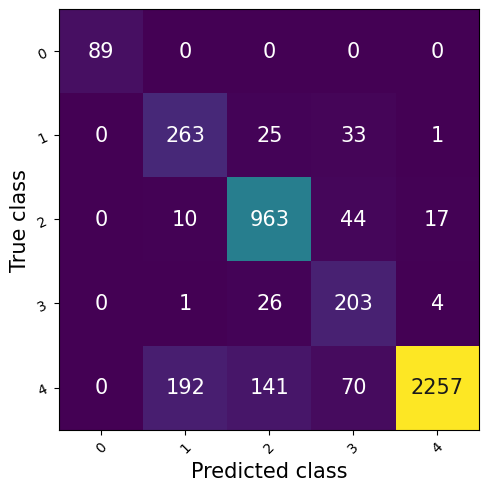

In [ ]:

print(f"Precision: {precision.compute()}")
print(f"Recall: {recall.compute()}")
print(f"F1 Score: {f1.compute()}")

fig, ax = confmat.plot()
plt.show()

In [ ]:
confmat.compute()

tensor([[  89,    0,    0,    0,    0],
        [   0,  263,   25,   33,    1],
        [   0,   10,  963,   44,   17],
        [   0,    1,   26,  203,    4],
        [   0,  192,  141,   70, 2257]], device='cuda:0')

In [ ]:
train_dataset.classes

['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']

In [ ]:
torch.cuda.device_count()

2

In [ ]:
best_f1

In [ ]:
torch.save(model.state_dict(), f='model.pth')

In [ ]:
print("hello")